In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import adjusted_rand_score
from scipy.stats import entropy

plt.style.use("seaborn-v0_8")

In [22]:
df = pd.read_csv("market_features_weekly.csv", parse_dates=["Date"], index_col="Date")
df_std = pd.read_csv("market_features_weekly_std.csv", parse_dates=["Date"], index_col="Date")

gmm = pd.read_csv("gmm_regimes.csv", index_col=0)
hmm = pd.read_csv("hmm_regimes.csv", index_col=0)

print(gmm.head())
print(hmm.head())


            SP500_Return       VIX  Yield_Spread  Regime_GMM Regime_label
Date                                                                     
1994-01-14      0.377339 -1.044307      0.656456           1         Calm
1994-01-21     -0.077835 -1.051667      0.689011           1         Calm
1994-01-28      0.284015 -1.192727      0.645604           1         Calm
1994-02-04     -0.836581 -0.541398      0.558790           1         Calm
1994-02-11     -0.028727 -0.638300      0.471976           1         Calm
            SP500_Return       VIX  Yield_Spread  Regime_HMM  Regime_label
Date                                                                      
1994-01-14      0.377339 -1.044307      0.656456           2  Transitional
1994-01-21     -0.077835 -1.051667      0.689011           2  Transitional
1994-01-28      0.284015 -1.192727      0.645604           2  Transitional
1994-02-04     -0.836581 -0.541398      0.558790           2  Transitional
1994-02-11     -0.028727 -0.6383

In [23]:
df.index = pd.to_datetime(df.index).normalize()
gmm.index = pd.to_datetime(gmm.index).normalize()
hmm.index = pd.to_datetime(hmm.index).normalize()
#convert to the same datetype

In [24]:
df["Regime_GMM"] = gmm["Regime_label"]
df["Regime_HMM"] = hmm["Regime_label"]

print(df)

                  SP500  SP500_Return    VIX  Yield_Spread Regime_GMM  \
Date                                                                    
1994-01-14   474.910004      0.010605  11.15          1.61       Calm   
1994-01-21   474.720001     -0.000400  11.09          1.64       Calm   
1994-01-28   478.700012      0.008349   9.94          1.60       Calm   
1994-02-04   469.809998     -0.018746  15.25          1.52       Calm   
1994-02-11   470.179993      0.000787  14.46          1.44       Calm   
...                 ...           ...    ...           ...        ...   
2023-12-01  4594.629883      0.007710  12.63         -0.34       Calm   
2023-12-08  4604.370117      0.002118  12.35         -0.48       Calm   
2023-12-15  4719.189941      0.024631  12.28         -0.53       Calm   
2023-12-22  4754.629883      0.007482  13.03         -0.41       Calm   
2023-12-29  4769.830078      0.003192  12.45         -0.35       Calm   

              Regime_HMM  
Date                   

In [25]:
assert df.isna().sum().sum() == 0
assert df_std.isna().sum().sum() == 0

print("Observations:", len(df))
print("GMM regimes:", df["Regime_GMM"].nunique())
print("HMM regimes:", df["Regime_HMM"].nunique())

Observations: 1564
GMM regimes: 3
HMM regimes: 3


In [26]:
def regime_durations(regimes):
    durations = []
    current = regimes.iloc[0]
    length = 1

    for r in regimes.iloc[1:]:
        if r == current:
            length += 1
        else:
            durations.append(length)
            current = r
            length = 1

    durations.append(length)
    return np.array(durations)

In [27]:
dur_gmm = regime_durations(df["Regime_GMM"])
dur_hmm = regime_durations(df["Regime_HMM"])

print("GMM mean duration:", dur_gmm.mean())
print("HMM mean duration:", dur_hmm.mean())


GMM mean duration: 8.988505747126437
HMM mean duration: 50.45161290322581


In [28]:
def transition_matrix(regimes):
    states = np.unique(regimes)
    mat = pd.DataFrame(0, index=states, columns=states)

    for i in range(len(regimes) - 1):
        mat.loc[regimes.iloc[i], regimes.iloc[i+1]] += 1

    return mat.div(mat.sum(axis=1), axis=0)


In [29]:
tm_gmm = transition_matrix(df["Regime_GMM"])
tm_hmm = transition_matrix(df["Regime_HMM"])

tm_gmm, tm_hmm

(                  Calm  Stressful  Transitional
 Calm          0.907675   0.065628      0.026696
 Stressful     0.121475   0.867679      0.010846
 Transitional  0.133005   0.009852      0.857143,
                   Calm  Stressful  Transitional
 Calm          0.985075   0.014925      0.000000
 Stressful     0.010076   0.967254      0.022670
 Transitional  0.004304   0.010043      0.985653)

In [30]:
def transition_entropy(tm):
    return entropy(tm.values, axis=1)

print("GMM transition entropy:", transition_entropy(tm_gmm))
print("HMM transition entropy:", transition_entropy(tm_hmm))

GMM transition entropy: [0.36340749 0.42829457 0.445967  ]
HMM transition entropy: [0.07757004 0.1643722  0.08390038]


In [31]:
ari = adjusted_rand_score(df["Regime_GMM"], df["Regime_HMM"])
print("Adjusted Rand Index (GMM vs HMM):", ari)

Adjusted Rand Index (GMM vs HMM): 0.2537944031819488


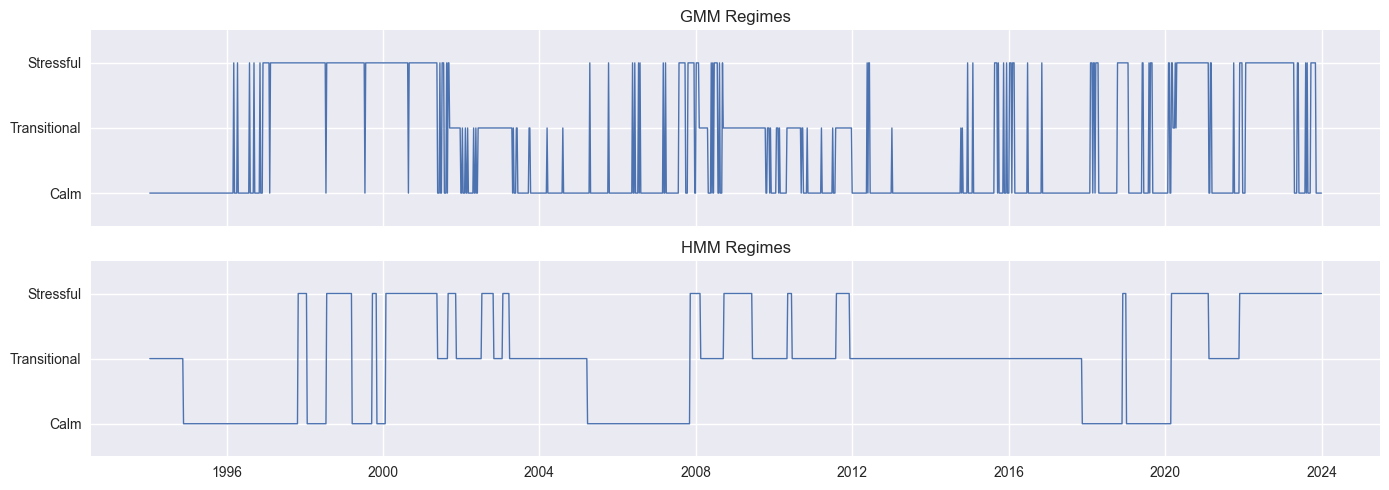

In [32]:
mapping = {'Calm': 0, 'Transitional': 1, 'Stressful': 2}

#We map periods to specific numbers, to give the proper order to the visualisation, unfortunately matplotlib implicitly assumes wrong order, so we have to adjust it manually


gmm_numeric = df["Regime_GMM"].map(mapping)
hmm_numeric = df["Regime_HMM"].map(mapping)

fig, ax = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax[0].plot(df.index, gmm_numeric, lw=1)
ax[0].set_title("GMM Regimes")

ax[1].plot(df.index, hmm_numeric, lw=1)
ax[1].set_title("HMM Regimes")

for a in ax:
    a.set_yticks([0, 1, 2])
    a.set_yticklabels(['Calm', 'Transitional', 'Stressful'])
    a.set_ylim(-0.5, 2.5)

plt.tight_layout()
plt.show()

In [33]:
features = ["SP500_Return", "VIX", "Yield_Spread"]

gmm_stats = df.groupby("Regime_GMM")[features].agg(["mean", "std"])
hmm_stats = df.groupby("Regime_HMM")[features].agg(["mean", "std"])

gmm_stats, hmm_stats

(             SP500_Return                  VIX            Yield_Spread  \
                      mean       std       mean        std         mean   
 Regime_GMM                                                               
 Calm             0.003530  0.012416  14.824233   3.011728     1.129756   
 Stressful       -0.001261  0.028779  23.758655   5.037425     0.285488   
 Transitional    -0.001370  0.043708  31.820690  11.194138     2.086404   
 
                         
                    std  
 Regime_GMM              
 Calm          0.876345  
 Stressful     0.505038  
 Transitional  0.387355  ,
              SP500_Return                  VIX            Yield_Spread  \
                      mean       std       mean        std         mean   
 Regime_HMM                                                               
 Calm             0.003332  0.016821  15.901620   4.268330     0.290277   
 Stressful       -0.001417  0.037907  28.199975  10.158221     0.559196   
 Transitional   

In [34]:
def max_drawdown(series):
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    return ((cum - peak) / peak).min()

dd_gmm = df.groupby("Regime_GMM")["SP500_Return"].apply(max_drawdown)
dd_hmm = df.groupby("Regime_HMM")["SP500_Return"].apply(max_drawdown)

dd_gmm, dd_hmm

(Regime_GMM
 Calm           -0.091550
 Stressful      -0.785472
 Transitional   -0.564429
 Name: SP500_Return, dtype: float64,
 Regime_HMM
 Calm           -0.104436
 Stressful      -0.773087
 Transitional   -0.257008
 Name: SP500_Return, dtype: float64)

In [35]:
print(df.head())

                 SP500  SP500_Return    VIX  Yield_Spread Regime_GMM  \
Date                                                                   
1994-01-14  474.910004      0.010605  11.15          1.61       Calm   
1994-01-21  474.720001     -0.000400  11.09          1.64       Calm   
1994-01-28  478.700012      0.008349   9.94          1.60       Calm   
1994-02-04  469.809998     -0.018746  15.25          1.52       Calm   
1994-02-11  470.179993      0.000787  14.46          1.44       Calm   

              Regime_HMM  
Date                      
1994-01-14  Transitional  
1994-01-21  Transitional  
1994-01-28  Transitional  
1994-02-04  Transitional  
1994-02-11  Transitional  


In [36]:
agreement = (df["Regime_HMM"] == df["Regime_GMM"]).mean()
print("Overall regime agreement:", agreement)

Overall regime agreement: 0.4296675191815857


In [37]:
split_date = "2005-01-01"

pre = df.loc[:split_date]
post = df.loc[split_date:]

ari_pre = adjusted_rand_score(pre["Regime_GMM"], pre["Regime_HMM"])
ari_post = adjusted_rand_score(post["Regime_GMM"], post["Regime_HMM"])

ari_pre, ari_post

#showcasing stability overtime

(0.26976530732076603, 0.24031823526031787)

In [38]:
summary = pd.DataFrame({
    "Metric": [
        "Mean Regime Duration",
        "Transition Entropy (avg)",
        "Max Drawdown (stress)",
        "ARI (GMM vs HMM)"
    ],
    "GMM": [
        dur_gmm.mean(),
        transition_entropy(tm_gmm).mean(),
        dd_gmm.min(),
        ari
    ],
    "HMM": [
        dur_hmm.mean(),
        transition_entropy(tm_hmm).mean(),
        dd_hmm.min(),
        ari
    ]
})

print(summary)

                     Metric       GMM        HMM
0      Mean Regime Duration  8.988506  50.451613
1  Transition Entropy (avg)  0.412556   0.108614
2     Max Drawdown (stress) -0.785472  -0.773087
3          ARI (GMM vs HMM)  0.253794   0.253794


In [39]:
#Key Findings
#HMM produces more persistent regimes with lower transition entropy
#GMM captures sharper cross-sectional distinctions but switches more frequently
#Both models align strongly during periods of market stress
#Regimes are economically interpretable and robust across time
